In [1]:
import boto3
import botocore
import sagemaker
import sys
from time import gmtime, strftime
from sagemaker import get_execution_role

/opt/conda/lib/python3.12/site-packages/pydantic/_internal/_fields.py:192: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [2]:
sess = sagemaker.Session()
bucket = "aws-ml-dl7"

print(f"Bucket: {bucket}")

role = get_execution_role()

print(f"Sagemaker IAM role: {role}")

prefix = "anomaly-detection/rcf-benchmarks"

downloaded_data_bucket = bucket
downloaded_data_prefix = "anomaly-detection/data/"
data_filename = "pedestrian_data.csv"

Bucket: aws-ml-dl7
Sagemaker IAM role: arn:aws:iam::148761651881:role/service-role/AmazonSageMaker-ExecutionRole-20250109T122909


In [3]:
print(f"Training input/output will be stored in: s3://{bucket}/{prefix}")
print(f"Downloaded training data will be read from s3://{downloaded_data_bucket}/{downloaded_data_prefix}")

Training input/output will be stored in: s3://aws-ml-dl7/anomaly-detection/rcf-benchmarks
Downloaded training data will be read from s3://aws-ml-dl7/anomaly-detection/data/


### Downolad data from S3 bucket

In [4]:
%%time 
import pandas as pd
import urllib.request


s3 = boto3.client("s3")

try:
    s3.download_file(downloaded_data_bucket, f"{downloaded_data_prefix}{data_filename}", data_filename)
    print("Data ready")
except:
    print('An error occured.')

pedestrian_data = pd.read_csv(data_filename, delimiter=',')

Data ready
CPU times: user 92.6 ms, sys: 19 ms, total: 112 ms
Wall time: 239 ms


### Time for EDA data

In [5]:
pedestrian_data.head()

,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


<Axes: >

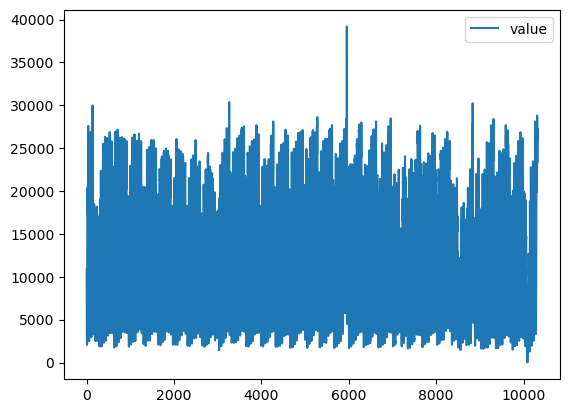

In [9]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

pedestrian_data.plot()


There is something uncharacterics occurs at around datapoint number 6000. Let's zoom in to examine to get a better picture.

<Axes: >

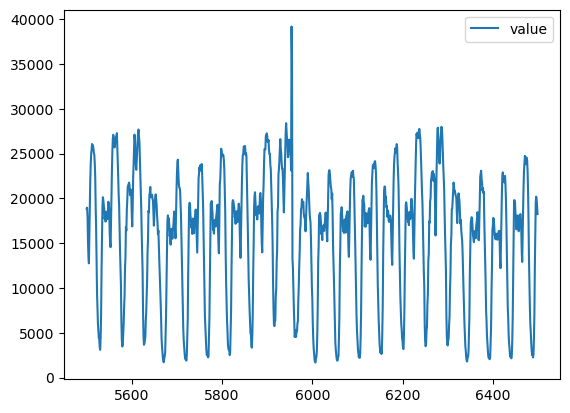

In [10]:
pedestrian_data[5500:6500].plot()

Also we can see now pedestarian walking patterns, the number of pedestrinas appers more or less periodic but as we mention close to 6000 datapoint we see something uncharacterstic.

<Axes: >

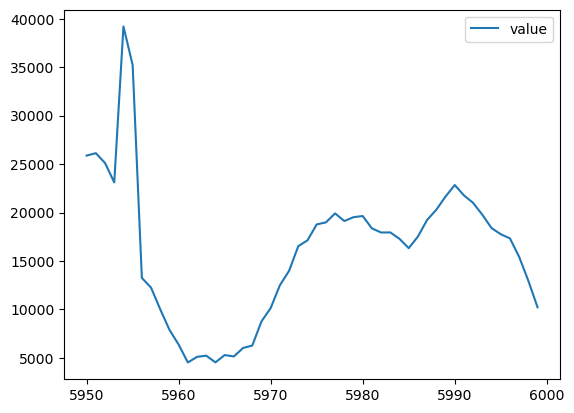

In [15]:
pedestrian_data[5950:6000].plot()

Let's check basic statistics for the whole data set by .describe() function on dataframe.

In [16]:
pedestrian_data.describe()

,value
count,10320.000000
mean,15137.569380
std,6939.495808
min,8.000000
25%,10262.000000
50%,16778.000000
75%,19838.750000
max,39197.000000


### Training 

Next set up training job to train the Random Cut Forest (RCF) algorthim on dataset.

In [17]:
print(f"{bucket}/{prefix}")

aws-ml-dl7/anomaly-detection/rcf-benchmarks


In [21]:
gmtime()

time.struct_time(tm_year=2025, tm_mon=5, tm_mday=1, tm_hour=9, tm_min=57, tm_sec=59, tm_wday=3, tm_yday=121, tm_isdst=0)

In [23]:
from sagemaker import RandomCutForest

session = sagemaker.Session()

# set up training job with hyperparamters for RandomCutForest algoritms

rcf = RandomCutForest(
    role=role,
    instance_count=1,
    data_location=f"s3://{bucket}/{prefix}",
    output_path=f"s3://{bucket}/{prefix}/output",
    instance_type="ml.m4.xlarge",
    num_samples_per_tree=256,
    num_trees=100,
    base_job_name=f"rcf-train-job-{strftime("%Y-%m-%d-%H-%M-%S", gmtime())}"
)

rcf.fit(rcf.record_set(pedestrian_data.value.to_numpy().reshape(-1,1)))
        

[05/01/25 09:58:21] INFO     Same images used for training and inference. Defaulting to image     ]8;id=180444;file:///opt/conda/lib/python3.12/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=463250;file:///opt/conda/lib/python3.12/site-packages/sagemaker/image_uris.py#393\393]8;;\
                             scope: inference.                                                                     

                    INFO     Ignoring unnecessary instance type: None.                            ]8;id=495394;file:///opt/conda/lib/python3.12/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=116015;file:///opt/conda/lib/python3.12/site-packages/sagemaker/image_uris.py#530\530]8;;\

                    INFO     Creating training-job with name:                                       ]8;id=842748;file:///opt/conda/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=119521;file:///opt/conda/lib/python3.12/site-packages/sagemaker/session.py#1042\1042]8;;\
                             rcf-train-job-2025-05-01-09-58-21-2025-05-01-09-58-21-550                             

2025-05-01 09:58:23 Starting - Starting the training job...
2025-05-01 09:58:38 Starting - Preparing the instances for training...
2025-05-01 09:59:05 Downloading - Downloading input data...
2025-05-01 09:59:30 Downloading - Downloading the training image.........
2025-05-01 10:01:21 Training - Training image download completed. Training in progress....
2025-05-01 10:01:54 Uploading - Uploading generated training modelDocker entrypoint called with argument(s): train
Running default environment configuration script
/opt/amazon/lib/python3.8/site-packages/mxnet/model.py:97: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if num_device is 1 and 'dist' not in kvstore:
/opt/amazon/lib/python3.8/site-packages/scipy/optimize/_shgo.py:495: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if cons['type'] is 'ineq':
/opt/amazon/lib/python3.8/site-packages/scipy/optimize/_shgo.py:743: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if len(self.X_min) is not 0:
[05/01

RCF model will be store in output_path specify in set up for training job. 

In [24]:
print(f"Traning job name: {rcf.latest_training_job.job_name}")

Traning job name: rcf-train-job-2025-05-01-09-58-21-2025-05-01-09-58-21-550


### Inference 

A traning RCF model we need to deploy to inference on data if we want to use the model.
We need to specify the instance type where inference is computed as well as an initial number of inscatnes to spin up.

In [25]:
endpoint_name = f"rcf-endpoint-{strftime('%Y-%m-%d-%H-%M-%S', gmtime())}"

rcf_inference = rcf.deploy(
    initial_instance_count=1,
    instance_type="ml.m4.xlarge",
    endpoint_name=endpoint_name
)

[05/01/25 10:04:03] INFO     Same images used for training and inference. Defaulting to image     ]8;id=814486;file:///opt/conda/lib/python3.12/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=989174;file:///opt/conda/lib/python3.12/site-packages/sagemaker/image_uris.py#393\393]8;;\
                             scope: inference.                                                                     

                    INFO     Ignoring unnecessary instance type: None.                            ]8;id=31815;file:///opt/conda/lib/python3.12/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=561153;file:///opt/conda/lib/python3.12/site-packages/sagemaker/image_uris.py#530\530]8;;\

                    INFO     Creating model with name:                                              ]8;id=466432;file:///opt/conda/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=712911;file:///opt/conda/lib/python3.12/site-packages/sagemaker/session.py#4094\4094]8;;\
                             rcf-train-job-2025-05-01-09-58-21-2025-05-01-10-04-03-138                             

[05/01/25 10:04:04] INFO     Creating endpoint-config with name rcf-endpoint-2025-05-01-10-04-03    ]8;id=440741;file:///opt/conda/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=948202;file:///opt/conda/lib/python3.12/site-packages/sagemaker/session.py#5937\5937]8;;\

                    INFO     Creating endpoint with name rcf-endpoint-2025-05-01-10-04-03           ]8;id=317785;file:///opt/conda/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=898106;file:///opt/conda/lib/python3.12/site-packages/sagemaker/session.py#4759\4759]8;;\

-----------!

In [26]:
print(f"Endpoint name: {rcf_inference.endpoint}")

[05/01/25 10:10:06] WARNING  The endpoint attribute has been renamed in sagemaker>=2.            ]8;id=953006;file:///opt/conda/lib/python3.12/site-packages/sagemaker/deprecations.py\deprecations.py]8;;\:]8;id=505338;file:///opt/conda/lib/python3.12/site-packages/sagemaker/deprecations.py#34\34]8;;\
                             See: https://sagemaker.readthedocs.io/en/stable/v2.html for                           
                             details.                                                                              

Endpoint name: rcf-endpoint-2025-05-01-10-04-03


In [28]:
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer

rcf_inference.serializer = CSVSerializer()
rcf_inference.deserializer = JSONDeserializer()

In [29]:
pedestrian_data_numpy = pedestrian_data.value.to_numpy().reshape(-1, 1)
results = rcf_inference.predict(pedestrian_data_numpy)
scores = [datum["score"] for datum in results["scores"]]

# add scores to taxi data frame and print first few values
pedestrian_data["score"] = pd.Series(scores, index=pedestrian_data.index)
pedestrian_data.head()

,timestamp,value,score
0,2014-07-01 00:00:00,10844,0.976621
1,2014-07-01 00:30:00,8127,0.935559
2,2014-07-01 01:00:00,6210,0.954961
3,2014-07-01 01:30:00,4656,0.886389
4,2014-07-01 02:00:00,3820,0.979928


<Axes: >

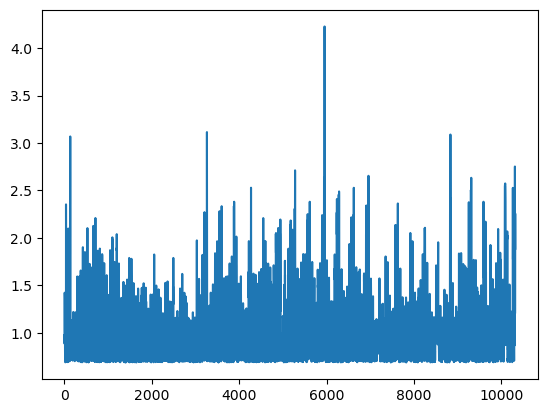

In [31]:
pedestrian_data["score"].plot()

In [33]:
pedestrian_data["score"].describe()

count    10320.000000
mean         0.978380
std          0.309064
min          0.687649
25%          0.765592
50%          0.902353
75%          1.056527
max          4.228208
Name: score, dtype: float64

In [46]:
pedestrian_data['outlier'] = round(pedestrian_data["score"], 1).quantile(0.99)

In [47]:
pedestrian_data['outlier']

0        2.2
1        2.2
2        2.2
3        2.2
4        2.2
        ... 
10315    2.2
10316    2.2
10317    2.2
10318    2.2
10319    2.2
Name: outlier, Length: 10320, dtype: float64

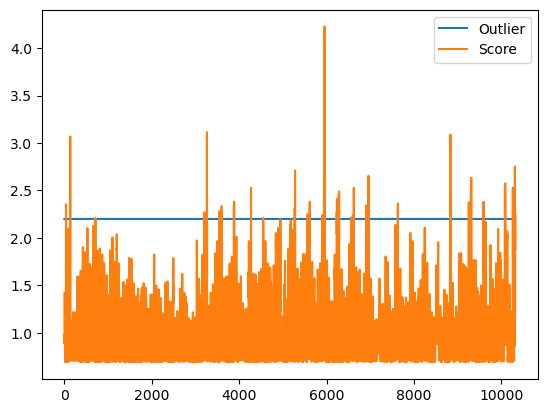

In [48]:
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots()

# Plot both series on the same axis
pedestrian_data['outlier'].plot.line(ax=ax, label='Outlier')
pedestrian_data['score'].plot(ax=ax, label='Score')

# Add legend and show the plot
ax.legend()
plt.show()


We can detect anomaly day in accroding our baseline. When we see score > outlier it means this day is nonusuall. We can assume this day appoint "Special event"